# Analisi stati da `main_SLURM_states.py`

Notebook per caricare i file `.npz` con stati evoluti (`states_eta_*.npz`) e calcolare:
- Concurrence (media e deviazione standard su traiettorie)
- Spin squeezing `\xi^2_{KU}` e `\xi^2_W` (media e deviazione standard su traiettorie)

In piu: grafici di fidelity sugli stati finali e visualizzazione tomografica (Re/Im/Abs/Phase della matrice densita finale media).
I grafici vengono salvati in PNG e PDF in `DATA_DIR/plots`.


In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qutip import Qobj, basis, concurrence, expect, fidelity, qeye, sigmax, sigmay, sigmaz, tensor

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True


In [2]:
# Imposta qui la cartella che contiene i .npz salvati dal cluster
DATA_DIR = Path(r"NPZ/N_2")


# Pattern per identificare i file .npz che contengono gli stati salvati. Assicurati che i file salvati seguano questo pattern.
NPZ_PATTERN = "states_eta_*.npz"

SAVE_PLOTS = True
DPI = 220

# Crea la cartella per i plot se non esiste già
PLOT_DIR = DATA_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Carica i file .npz che contengono gli stati salvati e stampa un riepilogo dei file trovati.
# sorted serve a garantire che i file vengano caricati in un ordine coerente, ad esempio ordinati per eta se il pattern include eta nei nomi dei file.
# glob cerca i file che corrispondono al pattern specificato nella cartella DATA_DIR.
npz_files = sorted(DATA_DIR.glob(NPZ_PATTERN))
print(f"Cartella: {DATA_DIR}")
print(f"File trovati: {len(npz_files)}")
for p in npz_files:
    print(' -', p.name)

if not npz_files:
    raise FileNotFoundError(f"Nessun file trovato con pattern '{NPZ_PATTERN}' in {DATA_DIR}")

print(f"Output plot: {PLOT_DIR}")


Cartella: NPZ\N_2
File trovati: 1
 - states_eta_1=1_eta_2=0.3.npz
Output plot: NPZ\N_2\plots


In [3]:
def infer_n_from_dim(dim: int) -> int:
    n = int(round(np.log2(dim)))
    if 2 ** n != dim:
        raise ValueError(f"Dimensione {dim} non compatibile con un sistema di qubit (2^N).")
    return n


def single_site_op(op, site: int, n_atoms: int):
    ops = [qeye(2) for _ in range(n_atoms)]
    ops[site] = op
    return tensor(ops)


def collective_spin_ops(n_atoms: int):
    jx = 0
    jy = 0
    jz = 0
    for i in range(n_atoms):
        jx += 0.5 * single_site_op(sigmax(), i, n_atoms)
        jy += 0.5 * single_site_op(sigmay(), i, n_atoms)
        jz += 0.5 * single_site_op(sigmaz(), i, n_atoms)
    return jx, jy, jz


def xi_ku_general(state, jx, jy, jz, n_atoms: int, tol: float = 1e-12):
    jx_exp = float(np.real_if_close(expect(jx, state)))
    jy_exp = float(np.real_if_close(expect(jy, state)))
    jz_exp = float(np.real_if_close(expect(jz, state)))
    jmean = np.array([jx_exp, jy_exp, jz_exp], dtype=float)
    m = np.linalg.norm(jmean)

    js = [jx, jy, jz]
    cov = np.zeros((3, 3), dtype=float)
    for i, ji in enumerate(js):
        for j, jj in enumerate(js):
            cov[i, j] = float(np.real_if_close(0.5 * expect(ji * jj + jj * ji, state) - jmean[i] * jmean[j]))

    if m > tol:
        uvec = jmean / m
        a = np.array([1.0, 0.0, 0.0]) if abs(uvec[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
        e1 = a - uvec * np.dot(uvec, a)
        e1 /= np.linalg.norm(e1)
        e2 = np.cross(uvec, e1)
        cov2 = np.array([[e1 @ cov @ e1, e1 @ cov @ e2], [e2 @ cov @ e1, e2 @ cov @ e2]], dtype=float)
        lam_min = float(np.linalg.eigvalsh(cov2)[0])
    else:
        lam_min = float(np.linalg.eigvalsh(cov)[0])

    lam_min = max(lam_min, 0.0)
    return float((4.0 / n_atoms) * lam_min)


def j_mean_norm(state, jx, jy, jz):
    jx_exp = float(np.real_if_close(expect(jx, state)))
    jy_exp = float(np.real_if_close(expect(jy, state)))
    jz_exp = float(np.real_if_close(expect(jz, state)))
    return float(np.linalg.norm([jx_exp, jy_exp, jz_exp]))


def xi_w_general(state, jx, jy, jz, n_atoms: int, tol: float = 1e-12):
    xi2_ku = xi_ku_general(state, jx, jy, jz, n_atoms=n_atoms, tol=tol)
    jnorm = j_mean_norm(state, jx, jy, jz)
    if jnorm <= tol:
        return np.nan
    return float(xi2_ku * (n_atoms / (2.0 * jnorm)) ** 2)


def concurrence_generic(state, n_atoms: int):
    if n_atoms == 2:
        return float(np.real_if_close(concurrence(state)))

    vals = []
    for i, j in combinations(range(n_atoms), 2):
        rho_ij = state.ptrace([i, j])
        vals.append(float(np.real_if_close(concurrence(rho_ij))))
    return float(np.mean(vals)) if vals else 0.0


def build_reference_states_n2():
    g = basis(2, 0)
    e = basis(2, 1)
    plus = (g + e).unit()
    minus = (g - e).unit()

    refs = {
        'gg': tensor(g, g),
        'ge': tensor(g, e),
        'eg': tensor(e, g),
        'ee': tensor(e, e),
        '++': tensor(plus, plus),
        '--': tensor(minus, minus),
        'phi+': (tensor(g, g) + tensor(e, e)).unit(),
        'phi-': (tensor(g, g) - tensor(e, e)).unit(),
        'psi+': (tensor(g, e) + tensor(e, g)).unit(),
        'psi-': (tensor(g, e) - tensor(e, g)).unit(),
    }
    return refs


def final_mean_rho(states_4d: np.ndarray, dims):
    # states_4d shape: (ntraj, nsteps, dim, dim)
    rho = np.mean(states_4d[:, -1, :, :], axis=0)
    rho = 0.5 * (rho + rho.conj().T)
    tr = np.trace(rho)
    if abs(tr) > 0:
        rho = rho / tr
    return Qobj(rho, dims=dims)


In [4]:
def compute_observables_from_npz(npz_path: Path):
    data = np.load(npz_path, allow_pickle=False)
    times = np.asarray(data['times'], dtype=float)
    states = np.asarray(data['states'])

    if states.ndim != 4:
        raise ValueError(f"Formato states non valido in {npz_path.name}: shape={states.shape}")

    ntraj, nsteps, dim0, dim1 = states.shape
    if dim0 != dim1:
        raise ValueError(f"Le matrici di stato non sono quadrate: {states.shape}")
    if len(times) != nsteps:
        raise ValueError(f"Numero tempi ({len(times)}) diverso da nsteps ({nsteps}) in {npz_path.name}")

    n_atoms = infer_n_from_dim(dim0)
    dims = [[2] * n_atoms, [2] * n_atoms]
    jx, jy, jz = collective_spin_ops(n_atoms)

    conc_arr = np.zeros((ntraj, nsteps), dtype=float)
    xi_ku_arr = np.zeros((ntraj, nsteps), dtype=float)
    xi_w_arr = np.zeros((ntraj, nsteps), dtype=float)
    j_norm_arr = np.zeros((ntraj, nsteps), dtype=float)

    # Fidelity tempo per tempo verso stati target (solo N=2)
    refs_n2 = build_reference_states_n2() if n_atoms == 2 else {}
    fid_arrays = {name: np.zeros((ntraj, nsteps), dtype=float) for name in refs_n2}

    for it in range(ntraj):
        for istt in range(nsteps):
            rho = Qobj(states[it, istt], dims=dims)
            conc_arr[it, istt] = concurrence_generic(rho, n_atoms)
            xi_ku_arr[it, istt] = xi_ku_general(rho, jx, jy, jz, n_atoms)
            xi_w_arr[it, istt] = xi_w_general(rho, jx, jy, jz, n_atoms)
            j_norm_arr[it, istt] = j_mean_norm(rho, jx, jy, jz)

            for name, ket in refs_n2.items():
                fid_arrays[name][it, istt] = float(np.real_if_close(fidelity(rho, ket)))

    out_dict = {
        'step': np.arange(nsteps, dtype=int),
        't': times,
        'Concurrence_mean': np.nanmean(conc_arr, axis=0),
        'Xi2_KU_mean': np.nanmean(xi_ku_arr, axis=0),
        'Xi2_W_mean': np.nanmean(xi_w_arr, axis=0),
        'J_Norm_mean': np.nanmean(j_norm_arr, axis=0),
        # Alias per compatibilita con le celle gia presenti
        'xi2_WIN_mean': np.nanmean(xi_w_arr, axis=0),
    }

    # Aggiungi tutte le fidelity al dataframe (mean/std tempo per tempo)
    for name, arr in fid_arrays.items():
        out_dict[f'Fidelity_{name}_mean'] = np.nanmean(arr, axis=0)
        out_dict[f'Fidelity_{name}_std'] = np.nanstd(arr, axis=0)

    out = pd.DataFrame(out_dict)

    meta = {
        'file': npz_path.name,
        'n_atoms': n_atoms,
        'ntraj': int(ntraj),
        'nsteps': int(nsteps),
        'eta_1': float(data['eta_1']) if 'eta_1' in data.files else np.nan,
        'eta_2': float(data['eta_2']) if 'eta_2' in data.files else np.nan,
        'phi1': float(data['phi1']) if 'phi1' in data.files else np.nan,
        'phi2': float(data['phi2']) if 'phi2' in data.files else np.nan,
    }

    rho_final = final_mean_rho(states, dims=dims)
    return out, meta, rho_final



In [5]:
results = {}
metas = {}
final_rhos = {}

for p in npz_files:
    df, meta, rho_final = compute_observables_from_npz(p)
    key = p.stem
    results[key] = df
    metas[key] = meta
    final_rhos[key] = rho_final

summary = pd.DataFrame(metas).T
summary

,file,n_atoms,ntraj,nsteps,eta_1,eta_2,phi1,phi2
states_eta_1=1_eta_2=0.3,states_eta_1=1_eta_2=0.3.npz,2,96,5000,1.0,0.3,0.0,0.0


In [6]:
df

,step,t,Concurrence_mean,Xi2_KU_mean,Xi2_W_mean,J_Norm_mean,xi2_WIN_mean,Fidelity_gg_mean,Fidelity_gg_std,Fidelity_ge_mean,...,Fidelity_--_mean,Fidelity_--_std,Fidelity_phi+_mean,Fidelity_phi+_std,Fidelity_phi-_mean,Fidelity_phi-_std,Fidelity_psi+_mean,Fidelity_psi+_std,Fidelity_psi-_mean,Fidelity_psi-_std
0,0,0.000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,0.500000,5.551115e-17,0.500000,...,0.000000,0.000000e+00,0.707107,3.330669e-16,0.000000,0.000000,0.707107,3.330669e-16,0.000000,0.000000
1,1,0.001,2.689891e-05,0.997983,1.000005,0.998988,1.000005,0.501323,2.063476e-02,0.499099,...,0.001000,5.016573e-12,0.706392,2.603640e-04,0.024412,0.016149,0.706500,7.647159e-04,0.031355,0.005179
2,2,0.002,7.087734e-05,0.996109,1.000012,0.998046,1.000012,0.499769,2.953880e-02,0.497766,...,0.001735,9.642498e-04,0.705728,4.464898e-04,0.033368,0.025147,0.705869,1.742567e-03,0.043649,0.006487
3,3,0.003,1.044397e-04,0.994422,1.000020,0.997197,1.000020,0.494009,3.631112e-02,0.496091,...,0.002402,1.627538e-03,0.705130,6.380762e-04,0.041867,0.030555,0.705199,2.782291e-03,0.052286,0.007547
4,4,0.004,1.394595e-04,0.992369,1.000024,0.996164,1.000024,0.493694,4.227947e-02,0.497500,...,0.003192,2.269814e-03,0.704403,1.121947e-03,0.048286,0.035841,0.704535,3.830602e-03,0.060787,0.010962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,4.995,4.581272e-15,0.490544,522440.504182,0.479716,522440.504182,0.262971,4.379540e-01,0.239416,...,0.499956,3.459263e-04,0.340667,3.518506e-01,0.340666,0.351851,0.368291,3.528584e-01,0.368291,0.352858
4996,4996,4.996,6.247270e-15,0.490531,523964.971581,0.479678,523964.971581,0.262884,4.379623e-01,0.239437,...,0.499958,3.337000e-04,0.340605,3.518831e-01,0.340604,0.351884,0.368297,3.528791e-01,0.368297,0.352879
4997,4997,4.997,5.911158e-15,0.490502,524998.428675,0.479615,524998.428675,0.262736,4.379792e-01,0.239472,...,0.499960,3.128216e-04,0.340501,3.519391e-01,0.340500,0.351940,0.368318,3.529018e-01,0.368318,0.352902
4998,4998,4.998,5.952546e-15,0.490544,525987.430334,0.479646,525987.430334,0.262816,4.379676e-01,0.239460,...,0.499959,3.233391e-04,0.340555,3.519088e-01,0.340555,0.351909,0.368314,3.528840e-01,0.368314,0.352884


In [7]:
df["factor"]= (2.0/ (2.0 * df["J_Norm_mean"])) ** 2
df["xi2_WIN_mean"]= df["Xi2_KU_mean"] * df["factor"]
df

,step,t,Concurrence_mean,Xi2_KU_mean,Xi2_W_mean,J_Norm_mean,xi2_WIN_mean,Fidelity_gg_mean,Fidelity_gg_std,Fidelity_ge_mean,...,Fidelity_--_std,Fidelity_phi+_mean,Fidelity_phi+_std,Fidelity_phi-_mean,Fidelity_phi-_std,Fidelity_psi+_mean,Fidelity_psi+_std,Fidelity_psi-_mean,Fidelity_psi-_std,factor
0,0,0.000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,0.500000,5.551115e-17,0.500000,...,0.000000e+00,0.707107,3.330669e-16,0.000000,0.000000,0.707107,3.330669e-16,0.000000,0.000000,1.000000
1,1,0.001,2.689891e-05,0.997983,1.000005,0.998988,1.000005,0.501323,2.063476e-02,0.499099,...,5.016573e-12,0.706392,2.603640e-04,0.024412,0.016149,0.706500,7.647159e-04,0.031355,0.005179,1.002027
2,2,0.002,7.087734e-05,0.996109,1.000012,0.998046,1.000012,0.499769,2.953880e-02,0.497766,...,9.642498e-04,0.705728,4.464898e-04,0.033368,0.025147,0.705869,1.742567e-03,0.043649,0.006487,1.003918
3,3,0.003,1.044397e-04,0.994422,1.000020,0.997197,1.000021,0.494009,3.631112e-02,0.496091,...,1.627538e-03,0.705130,6.380762e-04,0.041867,0.030555,0.705199,2.782291e-03,0.052286,0.007547,1.005630
4,4,0.004,1.394595e-04,0.992369,1.000024,0.996164,1.000027,0.493694,4.227947e-02,0.497500,...,2.269814e-03,0.704403,1.121947e-03,0.048286,0.035841,0.704535,3.830602e-03,0.060787,0.010962,1.007716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,4.995,4.581272e-15,0.490544,522440.504182,0.479716,2.131617,0.262971,4.379540e-01,0.239416,...,3.459263e-04,0.340667,3.518506e-01,0.340666,0.351851,0.368291,3.528584e-01,0.368291,0.352858,4.345415
4996,4996,4.996,6.247270e-15,0.490531,523964.971581,0.479678,2.131905,0.262884,4.379623e-01,0.239437,...,3.337000e-04,0.340605,3.518831e-01,0.340604,0.351884,0.368297,3.528791e-01,0.368297,0.352879,4.346115
4997,4997,4.997,5.911158e-15,0.490502,524998.428675,0.479615,2.132335,0.262736,4.379792e-01,0.239472,...,3.128216e-04,0.340501,3.519391e-01,0.340500,0.351940,0.368318,3.529018e-01,0.368318,0.352902,4.347255
4998,4998,4.998,5.952546e-15,0.490544,525987.430334,0.479646,2.132238,0.262816,4.379676e-01,0.239460,...,3.233391e-04,0.340555,3.519088e-01,0.340555,0.351909,0.368314,3.528840e-01,0.368314,0.352884,4.346679


Salvato: NPZ\N_2\plots\dynamics_observables.png
Salvato: NPZ\N_2\plots\dynamics_observables.pdf


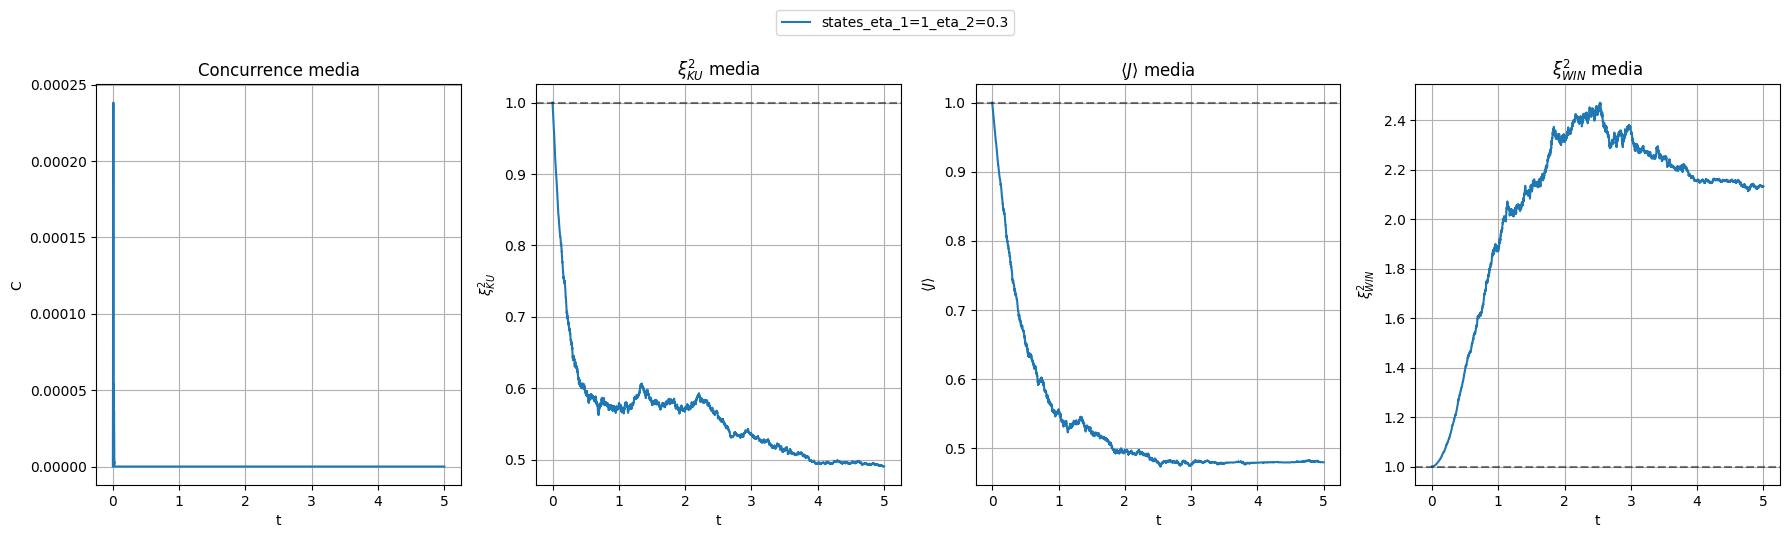

In [19]:
# Plot dinamiche medie e salvataggio in PNG/PDF
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=False)

for key, df in results.items():
    t = df['t'].to_numpy()
    axes[0].plot(t, df['Concurrence_mean'].to_numpy(), label=key)
    axes[1].plot(t, df['Xi2_KU_mean'].to_numpy(), label=key)
    axes[2].plot(t, df['J_Norm_mean'].to_numpy(), label=key)
    axes[3].plot(t, df['xi2_WIN_mean'].to_numpy(), label=key)

axes[0].set_title('Concurrence media')
axes[0].set_xlabel('t')
axes[0].set_ylabel('C')

axes[1].set_title(r'$\xi^2_{KU}$ media')
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$\xi^2_{KU}$')
axes[1].axhline(1.0, color='k', linestyle='--', alpha=0.5)

axes[2].set_title(r'$\langle J \rangle$ media')
axes[2].set_xlabel('t')
axes[2].set_ylabel(r'$\langle J \rangle$')
axes[2].axhline(1.0, color='k', linestyle='--', alpha=0.5)

axes[3].set_title(r'$\xi^2_{WIN}$ media')
axes[3].set_xlabel('t')
axes[3].set_ylabel(r'$\xi^2_{WIN}$')
axes[3].axhline(1.0, color='k', linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))

plt.tight_layout()

if SAVE_PLOTS:
    out_png = PLOT_DIR / 'dynamics_observables.png'
    out_pdf = PLOT_DIR / 'dynamics_observables.pdf'
    fig.savefig(out_png, dpi=DPI, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    print('Salvato:', out_png)
    print('Salvato:', out_pdf)

plt.show()


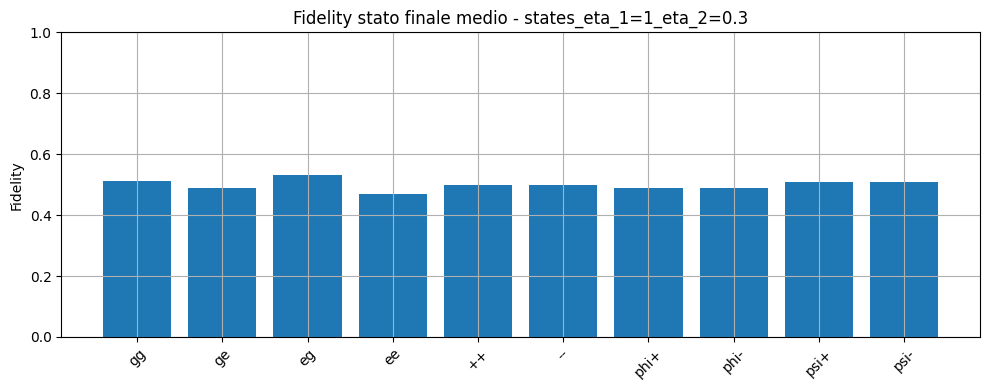

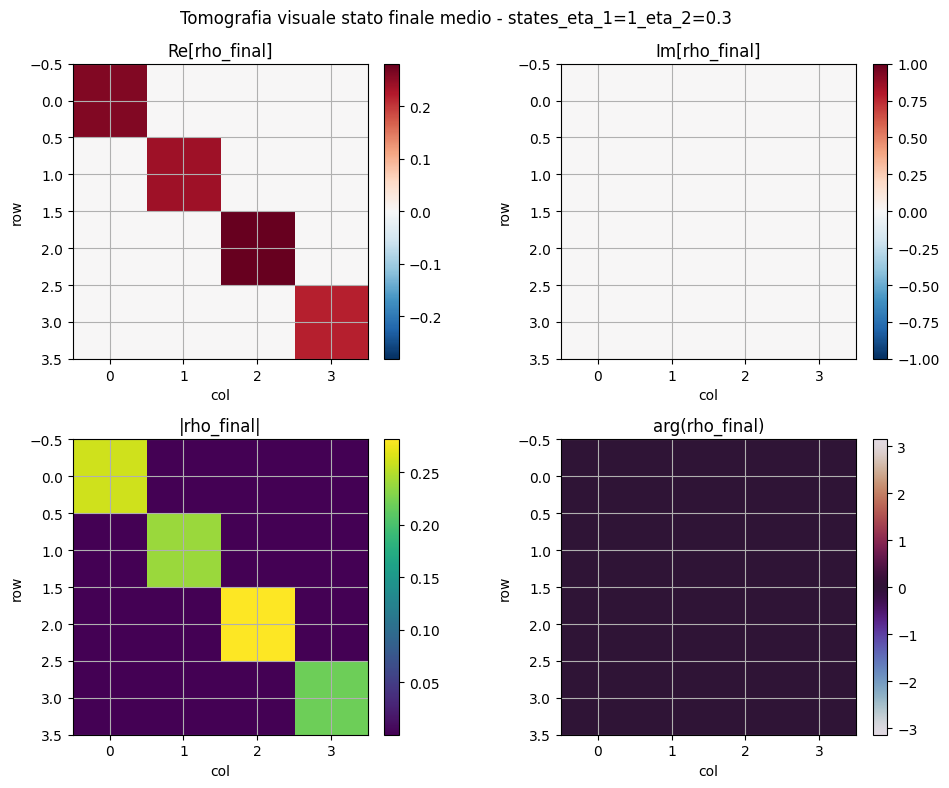

Plot salvati in: NPZ\N_2\plots


,file,target,fidelity
0,states_eta_1=1_eta_2=0.3,gg,0.510810
1,states_eta_1=1_eta_2=0.3,ge,0.488951
2,states_eta_1=1_eta_2=0.3,eg,0.530332
3,states_eta_1=1_eta_2=0.3,ee,0.467705
4,states_eta_1=1_eta_2=0.3,++,0.500042
5,states_eta_1=1_eta_2=0.3,--,0.499958
6,states_eta_1=1_eta_2=0.3,phi+,0.489732
7,states_eta_1=1_eta_2=0.3,phi-,0.489732
8,states_eta_1=1_eta_2=0.3,psi+,0.510062
9,states_eta_1=1_eta_2=0.3,psi-,0.510062


In [20]:
# Fidelity finali e tomografia (N=2)
refs_n2 = build_reference_states_n2()
fidelity_rows = []

for key, rho_final in final_rhos.items():
    n_atoms = int(metas[key]['n_atoms'])
    if n_atoms != 2:
        print(f"[skip] {key}: N={n_atoms} (questa sezione e impostata per N=2)")
        continue

    # 1) Barplot fidelity verso stati target
    fids = {name: float(np.real_if_close(fidelity(rho_final, ket))) for name, ket in refs_n2.items()}
    for name, val in fids.items():
        fidelity_rows.append({'file': key, 'target': name, 'fidelity': val})

    labels = list(fids.keys())
    values = [fids[x] for x in labels]

    fig1, ax1 = plt.subplots(figsize=(10, 4))
    ax1.bar(labels, values)
    ax1.set_ylim(0.0, 1.0)
    ax1.set_ylabel('Fidelity')
    ax1.set_title(f'Fidelity stato finale medio - {key}')
    ax1.tick_params(axis='x', rotation=45)
    plt.tight_layout()

    if SAVE_PLOTS:
        p1 = PLOT_DIR / f'{key}_final_fidelity.png'
        p2 = PLOT_DIR / f'{key}_final_fidelity.pdf'
        fig1.savefig(p1, dpi=DPI, bbox_inches='tight')
        fig1.savefig(p2, bbox_inches='tight')

    plt.show()

    # 2) Tomografia visuale della rho finale media
    mat = rho_final.full()
    re = np.real(mat)
    im = np.imag(mat)
    ab = np.abs(mat)
    ph = np.angle(mat)

    fig2, axs = plt.subplots(2, 2, figsize=(10, 8))

    vmax_re = np.max(np.abs(re)) if np.max(np.abs(re)) > 0 else 1.0
    vmax_im = np.max(np.abs(im)) if np.max(np.abs(im)) > 0 else 1.0

    im0 = axs[0, 0].imshow(re, cmap='RdBu_r', vmin=-vmax_re, vmax=vmax_re)
    axs[0, 0].set_title('Re[rho_final]')
    plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)

    im1 = axs[0, 1].imshow(im, cmap='RdBu_r', vmin=-vmax_im, vmax=vmax_im)
    axs[0, 1].set_title('Im[rho_final]')
    plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

    im2 = axs[1, 0].imshow(ab, cmap='viridis')
    axs[1, 0].set_title('|rho_final|')
    plt.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.04)

    im3 = axs[1, 1].imshow(ph, cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axs[1, 1].set_title('arg(rho_final)')
    plt.colorbar(im3, ax=axs[1, 1], fraction=0.046, pad=0.04)

    for ax in axs.ravel():
        ax.set_xlabel('col')
        ax.set_ylabel('row')

    fig2.suptitle(f'Tomografia visuale stato finale medio - {key}')
    plt.tight_layout()

    if SAVE_PLOTS:
        p3 = PLOT_DIR / f'{key}_final_tomography.png'
        p4 = PLOT_DIR / f'{key}_final_tomography.pdf'
        fig2.savefig(p3, dpi=DPI, bbox_inches='tight')
        fig2.savefig(p4, bbox_inches='tight')

    plt.show()

if SAVE_PLOTS:
    print('Plot salvati in:', PLOT_DIR)

fidelity_df = pd.DataFrame(fidelity_rows)
fidelity_df


In [ ]:
# Plot andamento di TUTTE le fidelity tempo per tempo
for key, df in results.items():
    fid_cols = [c for c in df.columns if c.startswith('Fidelity_') and c.endswith('_mean')]

    if not fid_cols:
        print(f"[info] {key}: nessuna colonna fidelity trovata")
        continue

    fig, ax = plt.subplots(figsize=(11, 5))
    t = df['t'].to_numpy()

    for col in fid_cols:
        label = col.replace('Fidelity_', '').replace('_mean', '')
        ax.plot(t, df[col].to_numpy(), linewidth=1.8, label=label)

    ax.set_title(f'Fidelity tempo per tempo - {key}')
    ax.set_xlabel('t')
    ax.set_ylabel('Fidelity')
    ax.set_ylim(0.0, 1.0)
    ax.legend(loc='best', ncol=2)
    plt.tight_layout()

    if SAVE_PLOTS:
        p_png = PLOT_DIR / f'{key}_fidelity_vs_time.png'
        p_pdf = PLOT_DIR / f'{key}_fidelity_vs_time.pdf'
        fig.savefig(p_png, dpi=DPI, bbox_inches='tight')
        fig.savefig(p_pdf, bbox_inches='tight')
        print('Salvato:', p_png)
        print('Salvato:', p_pdf)

    plt.show()

